In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import welch, coherence, csd, fftconvolve

In [2]:
data = np.load("./data/noise.npz")

source = data["source"]

error_noise = data["error_noise"]
ref_noise = data["ref_noise"]

error_nc = data["error_nc"]
ref_nc = data["ref_nc"]

error_ir = data["error_ir"]
ref_ir = data["ref_ir"]

error_ir_raw = data["error_ir_raw"]
ref_ir_raw = data["ref_ir_raw"]

fs = float(data["fs"])
ir_len = int(data["ir_len"])
panel_to_error_cm = float(data["panel_to_error_cm"])

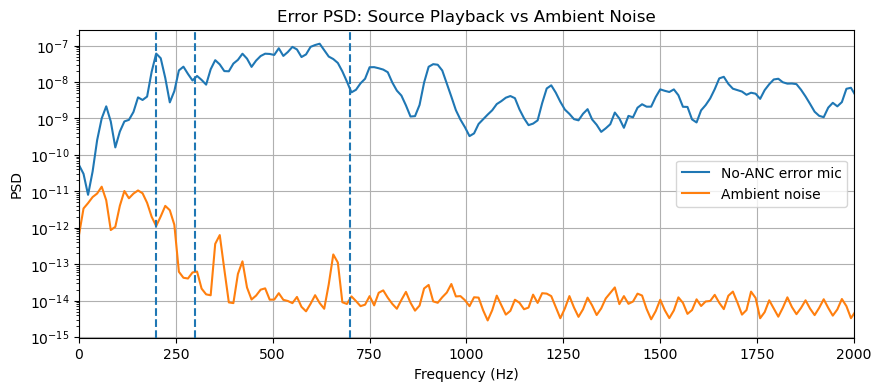

In [3]:
nperseg = 8192

f, P_nc = welch(error_nc, fs=fs, nperseg=nperseg)
_, P_noise = welch(error_noise, fs=fs, nperseg=nperseg)

plt.figure(figsize=(10, 4))

plt.semilogy(f, P_nc, label="No-ANC error mic")
plt.semilogy(f, P_noise, label="Ambient noise")

plt.axvline(200, linestyle="--")
plt.axvline(300, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 2000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Error PSD: Source Playback vs Ambient Noise")
plt.legend()
plt.grid()
plt.show()

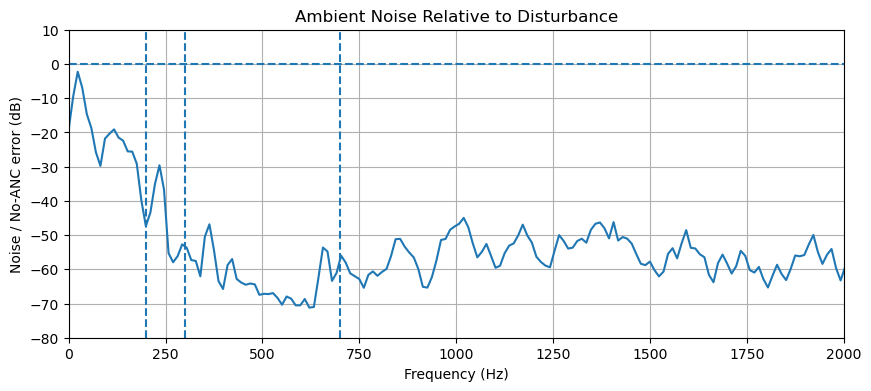

In [4]:
ratio_db = 10 * np.log10((P_noise + 1e-30) / (P_nc + 1e-30))

plt.figure(figsize=(10, 4))
plt.plot(f, ratio_db)

plt.axhline(0, linestyle="--")
plt.axvline(200, linestyle="--")
plt.axvline(300, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-80, 10)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Noise / No-ANC error (dB)")
plt.title("Ambient Noise Relative to Disturbance")
plt.grid()
plt.show()

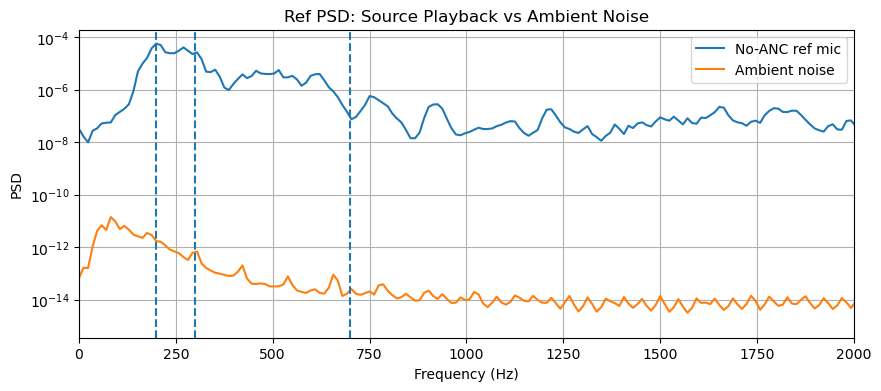

In [9]:
nperseg = 8192

f, P_ref_nc = welch(ref_nc, fs=fs, nperseg=nperseg)
_, P_ref_noise = welch(ref_noise, fs=fs, nperseg=nperseg)

plt.figure(figsize=(10, 4))

plt.semilogy(f, P_ref_nc, label="No-ANC ref mic")
plt.semilogy(f, P_ref_noise, label="Ambient noise")

plt.axvline(200, linestyle="--")
plt.axvline(300, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 2000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Ref PSD: Source Playback vs Ambient Noise")
plt.legend()
plt.grid()
plt.show()

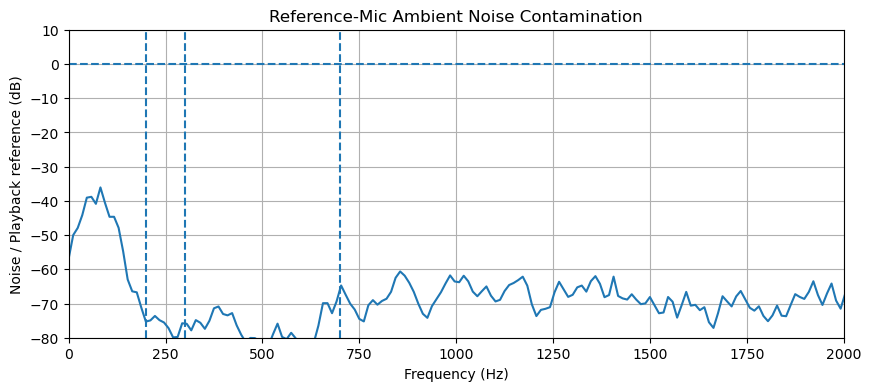

In [7]:
ratio_ref_db = 10 * np.log10(
    (P_ref_noise + 1e-30) /
    (P_ref_nc + 1e-30)
)

plt.figure(figsize=(10, 4))
plt.plot(f, ratio_ref_db)

plt.axhline(0, linestyle="--")
plt.axvline(200, linestyle="--")
plt.axvline(300, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-80, 10)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Noise / Playback reference (dB)")
plt.title("Reference-Mic Ambient Noise Contamination")
plt.grid()
plt.show()

In [ ]:
nperseg = 8192
NFFT = 8192


# FxLMS filtered reference
xf = fftconvolve(ref_nc, error_ir, mode="full")[:len(ref_nc)]

# PSDs
f, P_d = welch(error_nc, fs=fs, nperseg=nperseg)
_, P_xf = welch(xf, fs=fs, nperseg=nperseg)
_, P_ref = welch(ref_nc, fs=fs, nperseg=nperseg)

S = np.fft.rfft(error_ir, n=NFFT)
f_S = np.fft.rfftfreq(NFFT, d=1/fs)
S_power = np.abs(S)**2

bands = [
    (0, 200),
    (200, 300),
    (300, 700),
    (700, 1000),
    (1000, 2000),
    (2000, 5000),
]

def band_powers(f, P, bands):
    powers = []

    for lo, hi in bands:
        mask = (f >= lo) & (f < hi)
        powers.append(np.trapezoid(P[mask], f[mask]))

    return np.array(powers)

D_pow = band_powers(f, P_d, bands)
XF_pow = band_powers(f, P_xf, bands)
ref_pow = band_powers(f, P_ref, bands)
ir_pow = band_powers(f, P_ir, bands)

# Normalize each to its total 0–5 kHz power
D_pct = 100 * D_pow / np.sum(D_pow)
XF_pct = 100 * XF_pow / np.sum(XF_pow)
ref_pct = 100 * ref_pow / np.sum(ref_pow)
ir_pct = 100 * ir_pow / np.sum(ir_pow)

print("Band          Error power       Ref power      Raw IR power      Filtered-x power")

for (lo, hi), d, xf_p, ref_p, ir_p in zip(bands, D_pct, XF_pct, ref_pct, ir_pct):
    print(f"{lo:4d}-{hi:4d} Hz    {d:8.2f}%     {ref_p:8.2f}%       {ir_p:8.2f}%         {xf_p:8.2f}%")

Band          Error power       Ref power      Raw IR power      Filtered-x power
   0- 200 Hz        2.55%        22.25%           6.49%            21.30%
 200- 300 Hz        4.22%        48.04%           7.85%            60.00%
 300- 700 Hz       61.11%        27.09%          15.26%            17.62%
 700-1000 Hz       11.38%         0.92%           8.00%             0.38%
1000-2000 Hz       11.62%         1.26%          23.85%             0.59%
2000-5000 Hz        9.14%         0.44%          38.56%             0.10%


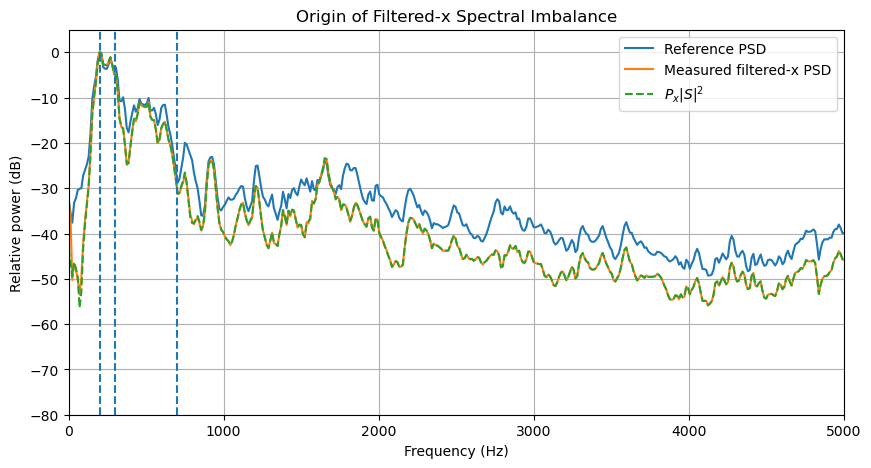

In [22]:
from scipy.signal import welch, fftconvolve
import numpy as np
import matplotlib.pyplot as plt

nperseg = 8192
NFFT = nperseg

# Actual filtered reference
xf = fftconvolve(ref_nc, error_ir, mode="full")[:len(ref_nc)]

f, P_ref = welch(
    ref_nc,
    fs=fs,
    nperseg=nperseg,
    nfft=NFFT
)

_, P_xf = welch(
    xf,
    fs=fs,
    nperseg=nperseg,
    nfft=NFFT
)

# Secondary-path frequency response
S = np.fft.rfft(error_ir, n=NFFT)
S2 = np.abs(S)**2

# What x_f PSD should look like from X and S
P_xf_pred = P_ref * S2

# Normalize for shape comparison
ref_db = 10*np.log10(P_ref + 1e-30)
xf_db = 10*np.log10(P_xf + 1e-30)
xf_pred_db = 10*np.log10(P_xf_pred + 1e-30)

ref_db -= np.max(ref_db)
xf_db -= np.max(xf_db)
xf_pred_db -= np.max(xf_pred_db)

plt.figure(figsize=(10, 5))

plt.plot(f, ref_db, label="Reference PSD")
plt.plot(f, xf_db, label="Measured filtered-x PSD")
plt.plot(f, xf_pred_db, "--", label=r"$P_x |S|^2$")

plt.axvline(200, linestyle="--")
plt.axvline(300, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 5000)
plt.ylim(-80, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative power (dB)")
plt.title("Origin of Filtered-x Spectral Imbalance")
plt.legend()
plt.grid()
plt.show()

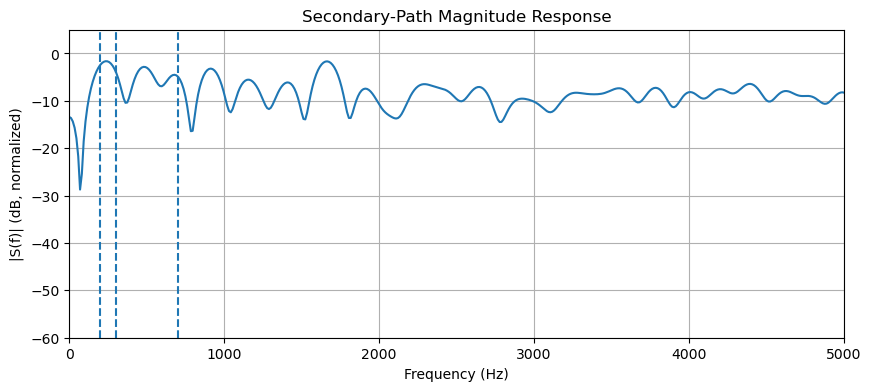

In [24]:
S_db = 20*np.log10(np.abs(S) + 1e-30)
S_db -= np.max(S_db)
f_S = np.fft.rfftfreq(NFFT, d=1/fs)


plt.figure(figsize=(10, 4))
plt.plot(f_S, S_db)

plt.axvline(200, linestyle="--")
plt.axvline(300, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 5000)
plt.ylim(-60, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("|S(f)| (dB, normalized)")
plt.title("Secondary-Path Magnitude Response")
plt.grid()
plt.show()

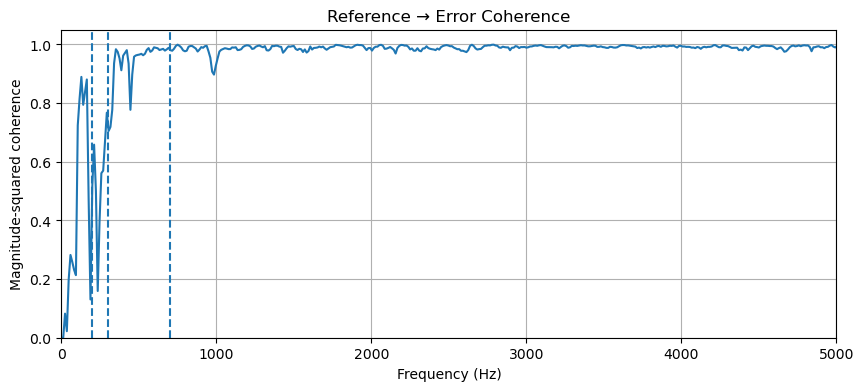

In [11]:
f_coh, coh = coherence(
    ref_nc,
    error_nc,
    fs=fs,
    nperseg=8192
)

plt.figure(figsize=(10, 4))
plt.plot(f_coh, coh)

plt.axvline(200, linestyle="--")
plt.axvline(300, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 5000)
plt.ylim(0, 1.05)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude-squared coherence")
plt.title("Reference → Error Coherence")
plt.grid()
plt.show()

In [ ]:
import librosa
import soundfile as sf
arthur, sr = sf.read('data/arthur_clip_48k.wav')
fs = 96_000
arthur_96 = librosa.resample(arthur, orig_sr=sr, target_sr=fs)
ad = AudioDevice(fs, in_device=1, out_device=4)

In [12]:
nperseg = 8192

# FxLMS filtered reference
xf = fftconvolve(ref_nc, error_ir[:256], mode="full")[:len(ref_nc)]

# PSDs
f, P_d = welch(error_nc, fs=fs, nperseg=nperseg)
_, P_xf = welch(xf, fs=fs, nperseg=nperseg)

bands = [
    (0, 200),
    (200, 300),
    (300, 700),
    (700, 1000),
    (1000, 2000),
    (2000, 5000),
]

def band_powers(f, P, bands):
    powers = []

    for lo, hi in bands:
        mask = (f >= lo) & (f < hi)
        powers.append(np.trapezoid(P[mask], f[mask]))

    return np.array(powers)

D_pow = band_powers(f, P_d, bands)
XF_pow = band_powers(f, P_xf, bands)

# Normalize each to its total 0–5 kHz power
D_pct = 100 * D_pow / np.sum(D_pow)
XF_pct = 100 * XF_pow / np.sum(XF_pow)

print("Band          Error power     Filtered-x power")

for (lo, hi), d, xf_p in zip(bands, D_pct, XF_pct):
    print(f"{lo:4d}-{hi:4d} Hz    {d:8.2f}%        {xf_p:8.2f}%")

Band          Error power     Filtered-x power
   0- 200 Hz        2.55%           17.22%
 200- 300 Hz        4.22%           51.20%
 300- 700 Hz       61.11%           29.96%
 700-1000 Hz       11.38%            0.56%
1000-2000 Hz       11.62%            0.87%
2000-5000 Hz        9.14%            0.18%


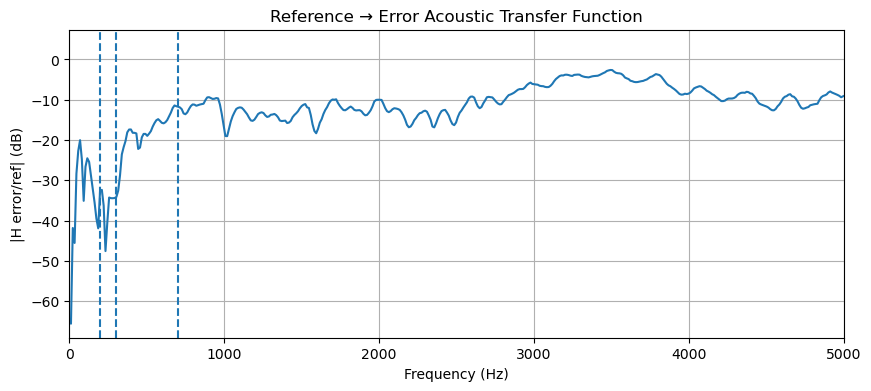

In [25]:
from scipy.signal import welch, csd
import numpy as np
import matplotlib.pyplot as plt

nperseg = 8192

# Reference autospectrum
f, P_rr = welch(
    ref_nc,
    fs=fs,
    nperseg=nperseg
)

# Cross spectrum: error relative to reference
_, P_er = csd(
    error_nc,
    ref_nc,
    fs=fs,
    nperseg=nperseg
)

H = P_er / (P_rr + 1e-30)

H_db = 20 * np.log10(np.abs(H) + 1e-30)

plt.figure(figsize=(10, 4))
plt.plot(f, H_db)

plt.axvline(200, linestyle="--")
plt.axvline(300, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 5000)

plt.xlabel("Frequency (Hz)")
plt.ylabel("|H error/ref| (dB)")
plt.title("Reference → Error Acoustic Transfer Function")
plt.grid()
plt.show()

In [26]:
f, P_source = welch(
    source,
    fs=fs,
    nperseg=8192
)

source_pow = band_powers(f, P_source, bands)
source_pct = 100 * source_pow / np.sum(source_pow)

print("Band          Source       Ref       Error")

for (lo, hi), s, r, d in zip(
    bands, source_pct, ref_pct, D_pct
):
    print(
        f"{lo:4d}-{hi:4d} Hz   "
        f"{s:8.2f}%   "
        f"{r:8.2f}%   "
        f"{d:8.2f}%"
    )

Band          Source       Ref       Error
   0- 200 Hz       3.91%      22.25%       2.55%
 200- 300 Hz      16.22%      48.04%       4.22%
 300- 700 Hz      67.62%      27.09%      61.11%
 700-1000 Hz       3.75%       0.92%      11.38%
1000-2000 Hz       6.80%       1.26%      11.62%
2000-5000 Hz       1.70%       0.44%       9.14%


In [27]:
import sounddevice as sd
import numpy as np
import soundfile as sf
from src.audio_device import AudioDevice
from src.sharc import Sharc
import matplotlib.pyplot as plt
import librosa
import mido
print(sd.query_devices())

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Analogue 1 + 2 (8- Focusrite US, MME (8 in, 0 out)
   2 Microphone Array (Intel® Smart , MME (4 in, 0 out)
   3 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  4 Realtek HD Audio 2nd output (Re, MME (0 in, 2 out)
   5 Speakers (8- Focusrite USB Audi, MME (0 in, 8 out)
   6 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   7 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   8 Analogue 1 + 2 (8- Focusrite USB Audio), Windows DirectSound (8 in, 0 out)
   9 Microphone Array (Intel® Smart Sound Technology (Intel® SST)), Windows DirectSound (4 in, 0 out)
  10 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  11 Realtek HD Audio 2nd output (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  12 Speakers (8- Focusrite USB Audio), Windows DirectSound (0 in, 8 out)
  13 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  14 Speakers (8- Focusrite USB Audio), Windows WASAPI (0 in, 2 out)
  1

In [28]:
arthur, sr = sf.read('data/arthur_clip_48k.wav')

fs = 96_000
arthur_96 = librosa.resample(arthur, orig_sr=sr, target_sr=fs)


ad = AudioDevice(fs, in_device=1, out_device=4)

In [41]:
error, ref = ad.play(left=arthur_96)

In [39]:
error_centered, ref_centered = ad.play(left=arthur_96)

In [47]:
error_further, ref_further = ad.play(left=arthur_96)

In [48]:
def band_power_table(
    signals,
    fs,
    bands=None,
    nperseg=8192,
):
    """
    Print normalized band-power percentages for any number of signals.

    Parameters
    ----------
    signals : dict
        Dictionary of {name: signal}, e.g.
        {
            "Source": source,
            "Ref": ref_nc,
            "Error": error_nc,
            "Filtered-x": xf,
        }

    fs : float
        Sample rate.

    bands : list of (low, high), optional
        Frequency bands in Hz.

    nperseg : int
        Welch PSD segment length.
    """

    if bands is None:
        bands = [
            (0, 200),
            (200, 300),
            (300, 700),
            (700, 1000),
            (1000, 2000),
            (2000, 5000),
        ]

    results = {}

    for name, signal in signals.items():

        # Avoid warning if signal is shorter than nperseg
        nseg = min(nperseg, len(signal))

        f, P = welch(
            signal,
            fs=fs,
            nperseg=nseg,
        )

        powers = []

        for lo, hi in bands:
            mask = (f >= lo) & (f < hi)
            powers.append(np.trapezoid(P[mask], f[mask]))

        powers = np.array(powers)

        # Normalize to total power within the specified bands
        results[name] = 100 * powers / np.sum(powers)

    # Print table
    header = f"{'Band':<15}"
    for name in signals:
        header += f"{name:>15}"
    print(header)

    for i, (lo, hi) in enumerate(bands):
        row = f"{lo:4d}-{hi:4d} Hz   "

        for name in signals:
            row += f"{results[name][i]:14.2f}%"

        print(row)

    return results

In [50]:
table = {
    "old error": error,
    "centered error": error_centered,
    "further error": error_further,
    "old ref": ref,
    "centered ref": ref_centered,
    "further ref": ref_further
}
result = band_power_table(table, fs, bands=bands)

Band                 old error centered error  further error        old ref   centered ref    further ref
   0- 200 Hz             1.86%          1.84%          1.80%         22.24%         21.11%         13.52%
 200- 300 Hz            11.88%         11.85%         12.17%         48.03%         46.05%         33.52%
 300- 700 Hz            62.39%         62.10%         62.89%         26.98%         28.68%         41.89%
 700-1000 Hz             8.77%          8.89%          7.74%          0.91%          1.16%          2.72%
1000-2000 Hz             8.49%          8.56%          8.64%          1.36%          2.11%          5.56%
2000-5000 Hz             6.62%          6.76%          6.76%          0.48%          0.89%          2.79%


In [51]:
xf_old = fftconvolve(
    ref_nc,
    error_ir[:256],
    mode="full"
)[:len(ref_nc)]

xf_further = fftconvolve(
    ref_further,
    error_ir[:256],
    mode="full"
)[:len(ref_further)]

band_power_table(
    {
        "Ref old": ref_nc,
        "Ref further": ref_further,
        "XF old": xf_old,
        "XF further": xf_further,
    },
    fs
)

Band                   Ref old    Ref further         XF old     XF further
   0- 200 Hz            22.25%         13.52%         17.22%         10.84%
 200- 300 Hz            48.04%         33.52%         51.20%         36.83%
 300- 700 Hz            27.09%         41.89%         29.96%         45.55%
 700-1000 Hz             0.92%          2.72%          0.56%          1.68%
1000-2000 Hz             1.26%          5.56%          0.87%          3.91%
2000-5000 Hz             0.44%          2.79%          0.18%          1.18%


{'Ref old': array([22.2451446 , 48.04362724, 27.09139788,  0.92053372,  1.26391237,
         0.4353842 ]),
 'Ref further': array([13.51707279, 33.52086986, 41.89357726,  2.71844836,  5.55855286,
         2.79147886]),
 'XF old': array([17.22351441, 51.20457506, 29.96286582,  0.56071896,  0.86963231,
         0.17869344]),
 'XF further': array([10.84176455, 36.82719092, 45.55265801,  1.68050043,  3.91340217,
         1.18448392])}

In [54]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import welch, coherence, csd, fftconvolve


all_irs = np.load('./data/multiple_irs.npz')
error_4_5 = all_irs["error_4_5"]
error_11 = all_irs["error_11"]
error_27 = all_irs["error_27"]
ref_4_5 = all_irs["ref_4_5"]
ref_11 = all_irs["ref_11"]
ref_27 = all_irs["ref_27"]
dist_4_5 = all_irs["dist_4_5"]
dist_11 = all_irs["dist_11"]
dist_27 = all_irs["dist_27"]
fs = float(all_irs["fs"])

In [56]:
irs = {
    "4.5 cm": error_4_5,
    "11 cm": error_11,
    "27 cm": error_27,
}

for name, ir in irs.items():
    peak = np.argmax(np.abs(ir))
    print(f"{name:8s}: peak = {peak:7d} samples, {peak/fs*1000:.3f} ms")

4.5 cm  : peak =  619760 samples, 6455.833 ms
11 cm   : peak =  621695 samples, 6475.990 ms
27 cm   : peak =  619723 samples, 6455.448 ms


In [57]:
p0 = np.argmax(np.abs(error_4_5))

for name, ir in irs.items():
    p = np.argmax(np.abs(ir))
    ds = p - p0

    print(
        f"{name:8s}: Δ = {ds:4d} samples = "
        f"{ds/fs*1000:.3f} ms = "
        f"{ds/fs*343*100:.1f} cm"
    )

4.5 cm  : Δ =    0 samples = 0.000 ms = 0.0 cm
11 cm   : Δ = 1935 samples = 20.156 ms = 691.4 cm
27 cm   : Δ =  -37 samples = -0.385 ms = -13.2 cm


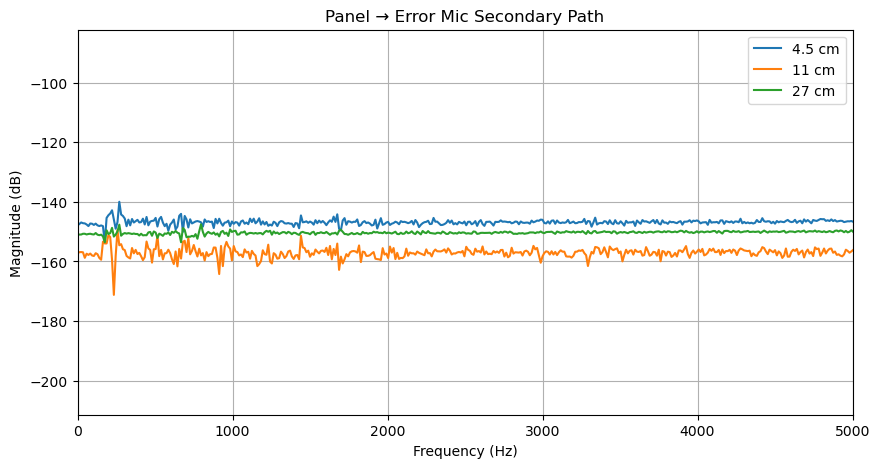

In [58]:
NFFT = 8192

freqs = np.fft.rfftfreq(NFFT, d=1/fs)

S_4_5 = np.fft.rfft(error_4_5, n=NFFT)
S_11  = np.fft.rfft(error_11,  n=NFFT)
S_27  = np.fft.rfft(error_27,  n=NFFT)

plt.figure(figsize=(10, 5))

for S, label in [
    (S_4_5, "4.5 cm"),
    (S_11,  "11 cm"),
    (S_27,  "27 cm"),
]:
    mag_db = 20 * np.log10(np.abs(S) + 1e-12)
    plt.plot(freqs, mag_db, label=label)

plt.xlim(0, 5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Panel → Error Mic Secondary Path")
plt.grid()
plt.legend()
plt.show()

In [59]:
def crop_ir_around_peak(ir, pre=100, length=4096):
    peak = np.argmax(np.abs(ir))
    start = max(0, peak - pre)
    return ir[start:start + length]

e45 = crop_ir_around_peak(error_4_5)
e11 = crop_ir_around_peak(error_11)
e27 = crop_ir_around_peak(error_27)

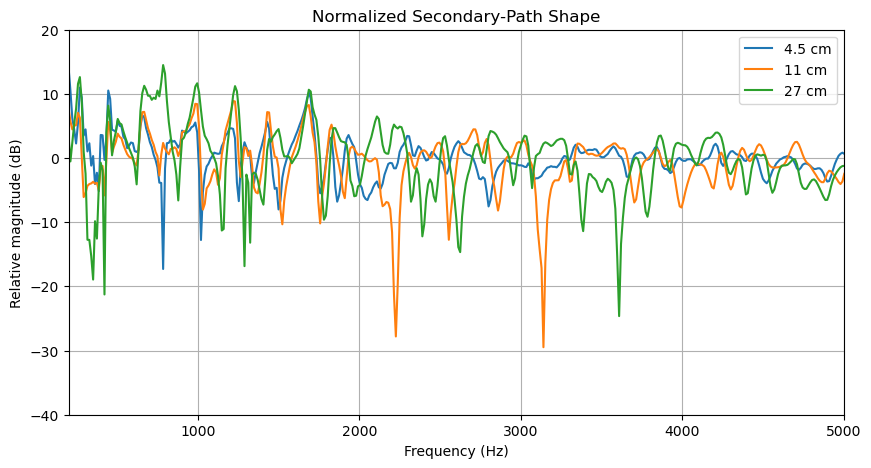

In [60]:
responses = {
    "4.5 cm": e45,
    "11 cm": e11,
    "27 cm": e27,
}

NFFT = 8192
freqs = np.fft.rfftfreq(NFFT, d=1/fs)
band = (freqs >= 200) & (freqs <= 5000)

plt.figure(figsize=(10, 5))

for name, ir in responses.items():
    S = np.fft.rfft(ir, n=NFFT)
    mag_db = 20 * np.log10(np.abs(S) + 1e-12)

    # Normalize by median magnitude over our band
    mag_db -= np.median(mag_db[band])

    plt.plot(freqs, mag_db, label=name)

plt.xlim(200, 5000)
plt.ylim(-40, 20)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative magnitude (dB)")
plt.title("Normalized Secondary-Path Shape")
plt.grid()
plt.legend()
plt.show()

In [61]:
for name, ir in responses.items():
    S = np.fft.rfft(ir, n=NFFT)
    mag_db = 20 * np.log10(np.abs(S) + 1e-12)

    vals = mag_db[band]

    p10, p90 = np.percentile(vals, [10, 90])

    print(
        f"{name:8s}: "
        f"std = {np.std(vals):5.2f} dB, "
        f"10–90% span = {p90 - p10:5.2f} dB"
    )

4.5 cm  : std =  3.17 dB, 10–90% span =  7.62 dB
11 cm   : std =  4.56 dB, 10–90% span = 10.00 dB
27 cm   : std =  5.48 dB, 10–90% span = 12.06 dB


In [62]:
def crop_ir(ir, pre=100, length=1024):
    peak = np.argmax(np.abs(ir))
    start = max(0, peak - pre)
    return ir[start:start + length]

s_4_5 = crop_ir(error_4_5)
s_11  = crop_ir(error_11)
s_27  = crop_ir(error_27)

xf_4_5 = fftconvolve(ref_further, s_4_5, mode="full")[:len(ref_further)]
xf_11  = fftconvolve(ref_further, s_11,  mode="full")[:len(ref_further)]
xf_27  = fftconvolve(ref_further, s_27,  mode="full")[:len(ref_further)]

band_power_table(
    {
        "Ref": ref_further,
        "XF 4.5cm": xf_4_5,
        "XF 11cm": xf_11,
        "XF 27cm": xf_27,
    },
    fs
)

Band                       Ref       XF 4.5cm        XF 11cm        XF 27cm
   0- 200 Hz            13.52%         19.25%         20.35%         13.06%
 200- 300 Hz            33.52%         47.07%         45.38%         47.09%
 300- 700 Hz            41.89%         28.91%         26.01%         27.12%
 700-1000 Hz             2.72%          0.90%          1.74%          6.95%
1000-2000 Hz             5.56%          3.19%          5.36%          4.45%
2000-5000 Hz             2.79%          0.67%          1.16%          1.33%


{'Ref': array([13.51707279, 33.52086986, 41.89357726,  2.71844836,  5.55855286,
         2.79147886]),
 'XF 4.5cm': array([19.24600217, 47.07415535, 28.91046245,  0.90208944,  3.19450741,
         0.67278318]),
 'XF 11cm': array([20.34912538, 45.37901517, 26.01432666,  1.74177377,  5.35772875,
         1.15803026]),
 'XF 27cm': array([13.05938624, 47.08510793, 27.12261735,  6.95189401,  4.44990603,
         1.33108844])}